# 核心问题
这篇论文回答了一个在LLM强化学习训练中至关重要但长期被忽视的问题：
- **为什么RL训练LLM时，策略熵会单调下降直至崩溃？**
- <font color='red'>这种崩溃如何限制了模型的性能上限？</font>
- **我们能否从机制层面理解并控制它？**

# 第一部分：熵崩溃的经验规律（第2节）
## 观察到的现象
论文在4个模型家族、11个基础模型（0.5B-32B参数）、数学和代码任务上进行了大规模实验，发现了一个惊人的一致模式：

| 阶段                 | 熵变化     | 性能变化       |
| ------------------ | ------- | ---------- |
| **前200步**（1/12训练）  | 消耗73%的熵 | 获得76%的性能提升 |
| **前800步**（1/3训练）   | 消耗94%的熵 | 获得93%的性能提升 |
| <font color='red'>**剩余1600步**（2/3训练）</font> | **仅消耗6%的熵** | 仅获得5%的性能提升 |


关键发现：**超过2/3的训练步骤几乎"白跑"——熵已经耗尽，模型无法继续探索新路径。**

### 核心经验定律：$R=−a⋅e^H + b$
- 论文发现，**验证性能R** 与 **策略熵H** 之间存在精确的指数关系：
  - R=−a⋅exp(H)+b 
  - 其中 a,b  是拟合系数，仅取决于模型和数据的内在特性。


In [1]:
from IPython.display import Image

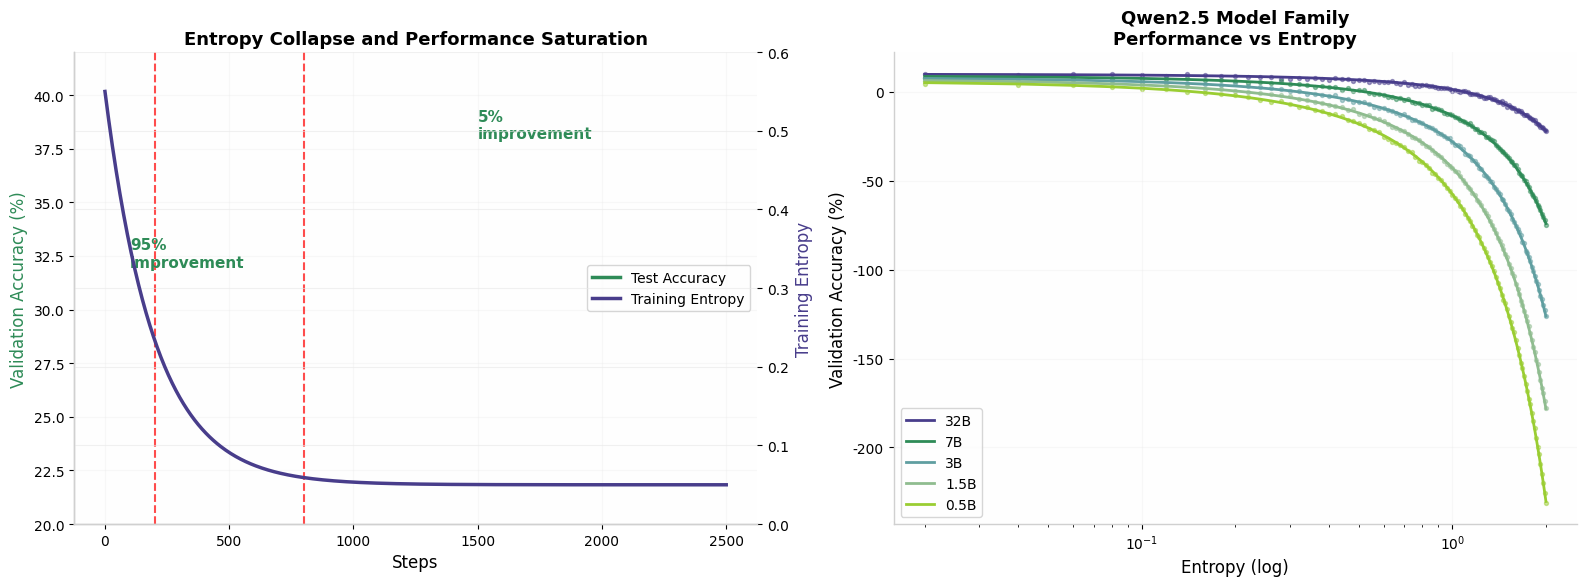

In [2]:
Image(filename='./Image/f1.png')

#### 这个定律的深刻含义：
1. 可预测性：像神经缩放定律（Scaling Laws）一样，**给定模型和数据**，性能-熵曲线是预先确定的
2. 性能天花板：当 H→0  时，R→−a+b ，<font color='red'>性能上限完全可预测</font>
3. 扩展RL的瓶颈：<font color='blue'>单纯增加训练计算量（更多步数）收益边际递减，因为熵已经耗尽</font>

## 跨模型预测能力
<font color='red'>仅用前36步的数据拟合曲线，就能准确预测后续200步的性能（虚线与实线几乎重合）：</font>



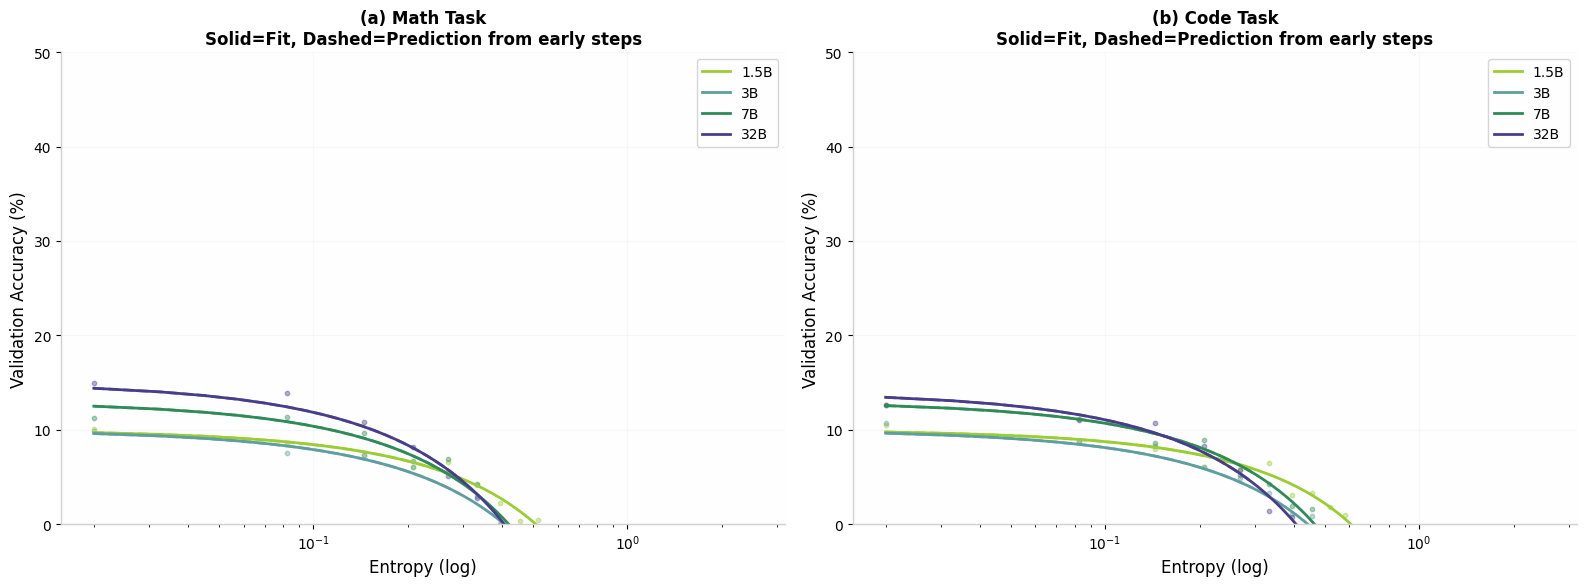

In [3]:
Image(filename='./Image/f5.png')

# 第二部分：熵动力学的理论机制（第3节）
## 核心定理
对于softmax参数化的策略（如LLM），**熵的变化由以下协方差驱动**：
 $ ΔH∝−Cov(logπθ(y_t),Δz_t) $
### 其中：
- $π_θ(yt)$  是动作（token）概率
- $Δz_t$是logit变化量
- 在Policy Gradient类算法下，$Δz_t∝A_t$(优势函数）

## 直观解释

| 情况          | 协方差符号 | 熵变化    | 含义                   |
| ----------- | ----- | ------ | -------------------- |
| 高概率动作 + 高优势 | 正     | **减少** | 模型"确信"这个好答案，进一步集中概率  |
| 低概率动作 + 高优势 | 负     | **增加** | 发现"黑马"好答案，增加探索       |
| 高概率动作 + 低优势 | 负     | **增加** | 模型发现之前确信的动作其实不好，分散概率 |

## 为什么熵会单调下降？
**关键发现：协方差项在训练过程中始终保持为正！**

In [ ]:
训练初期：协方差很高 → 模型信心校准良好 → 安全地利用高置信轨迹
         ↓
训练中期：协方差逐渐下降但仍为正 → 继续拖拽熵下降
         ↓
训练后期：协方差接近0但仍为正 → 熵趋近于0，模型极度确定

# 第三部分：基于协方差的熵控制方法（第4节）
## 为什么传统熵正则化不够？
论文证明，**传统的熵正则化（在loss中加 −βH ）会引入密集、持续的偏差**，修改了 stationary condition，导致次优策略。

## 提出的新方法：<font color='red'>协方差正则化</font>
- 核心思想：<font color='blue'>限制高协方差token的更新步长，因为这些token是熵下降的主要驱动力。</font>
### 方法1：Clip-Cov


In [ ]:
# 伪代码
cov = log_prob * advantage  # 计算协方差
if cov > threshold:
    gradient = detach(gradient)  # 阻断这些token的梯度

- 随机选择一小部分正协方差token
- 阻断它们的梯度更新
- 简单有效，但可能过于粗糙

### 方法2：KL-Cov

In [ ]:
# 伪代码
cov = log_prob * advantage
top_k_tokens = select_top_k(cov)  # 选择协方差最大的token
kl_penalty = KL_divergence(current_policy, ref_policy, mask=top_k_tokens)
loss += kl_penalty

- <font color='red'>对协方差最大的token施加KL惩罚</font>
- 更精细地控制更新幅度
- 通过调节阈值参数主动控制熵水平

## 实验结果

| 方法           | MATH500  | AIME 2024 | 熵控制效果     |
| ------------ | -------- | --------- | --------- |
| 基线（无干预）      | ~35%     | ~10%      | 熵崩溃至0     |
| 传统熵正则化       | ~36%     | ~11%      | 轻微提升，仍有偏差 |
| **Clip-Cov** | **~40%** | **~15%**  | 熵稳定在中等水平  |
| **KL-Cov**   | <font color='red'>**~42%**</font> | **~17%**  | 最佳熵控制     |


## 与其他工作的关系

| 相关工作                              | 核心思想               | 与本文关系                                  |
| --------------------------------- | ------------------ | -------------------------------------- |
| **DAPO** (Yu et al., 2025)        | Clip-Higher机制缓解熵崩溃 |** 本文从理论上解释了为什么Clip-Higher有效（它间接影响了协方差分布）** |
| **EntroPIC** (Arora et al., 2025) | 动态调整高概率样本的权重       | 本文提供了更底层的机制理解                          |
| **SENT** (后续工作)                   | 语义熵 + token熵双重正则化  | 直接建立在本文的协方差框架上                         |
| **RAGEN-2** (2026)                | 模板崩溃 + 互信息诊断       | 扩展了本文的熵分析到多轮agent场景                    |

## 核心贡献总结

| # | 贡献                                                                               |
| - | -------------------------------------------------------------------------------- |
| 1 | **发现经验定律**：$R = -a \cdot e^H + b$，揭示性能与熵的指数 trade-off                            |
| 2 | **理论机制**：证明熵变化由 $\text{Cov}(\log \pi, \Delta z)$ 驱动，且在PG算法下 $\Delta z \propto A$ |
| 3 | **解释单调下降**：协方差始终为正，导致熵不可逆地下降                                                     |
| 4 | **提出新方法**：Clip-Cov 和 KL-Cov， <font color='red'>通过限制高协方差token更新来控制熵 </font>                                 |
| 5 | **验证有效性**：在多个模型家族和任务上证明方法能逃离熵崩溃，提升性能                                             |

## 实践启示
- 监控协方差比监控熵更重要——**协方差是熵变化的"先行指标"**
- <font color='red'>不要盲目增加训练步数——如果熵已经耗尽，更多计算是浪费</font>
- 选择性正则化优于全局正则化——<font color='blue'>只限制高协方差token，保留其他token的正常更新</font>
- 早期预测能力——用前几十步数据拟合 $R=−a⋅e^H+b$ ，可以预测最终性能天花板

## 一句话总结
这篇论文揭示了LLM RL训练中一个深刻的"熵-性能 trade-off"：模型用熵（探索能力）换取性能，且遵循精确的指数定律 $R=−a⋅e^H+b$ 。
- 通过理论分析，**论文发现熵下降由"概率-优势协方差"驱动**，并据此设计了Clip-Cov和KL-Cov方法——不是盲目地给所有token加熵奖励，而是精准地"刹车"那些最贪婪消耗熵的高协方差token。
- 这是一种从"治标"到"治本"的范式转变。